In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df = pd.read_excel("cleaned_data.xlsx")

In [6]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [7]:
df.count()

OrderID            1200
Date               1200
CustomerID         1200
Product            1200
Quantity           1200
UnitPrice          1200
ShippingAddress    1200
PaymentMethod      1200
OrderStatus        1200
TrackingNumber     1200
ItemsInCart        1200
CouponCode         1200
ReferralSource     1200
TotalPrice         1200
dtype: int64

In [8]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].mean()

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

In [9]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].median()

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

<Axes: xlabel='Date'>

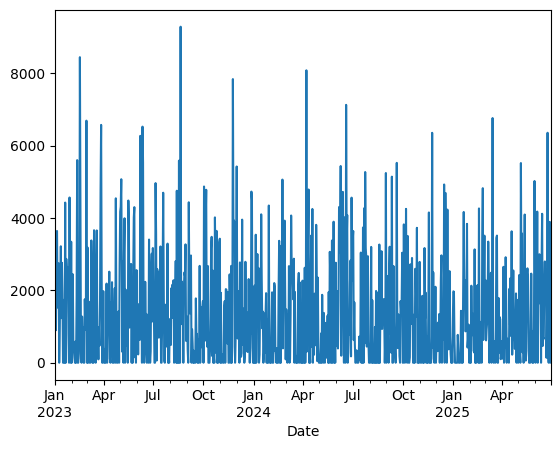

In [10]:
df.set_index('Date')['TotalPrice'].resample('D').sum().plot(kind='line')

In [11]:
df['Year'] = df['Date'].dt.year

In [12]:
df_half = df[df['Date'].dt.month <= 6]

<Axes: xlabel='Year'>

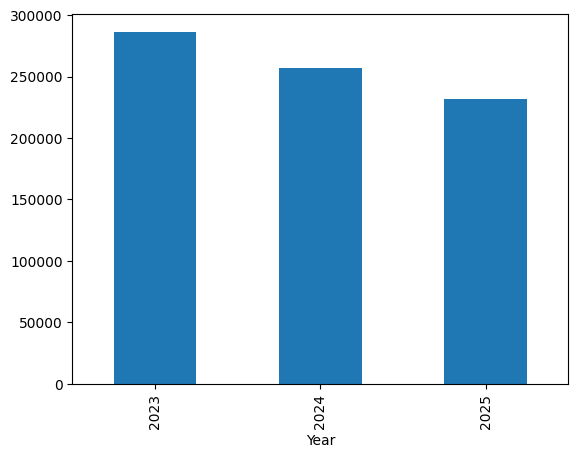

In [13]:
df_half.groupby('Year')['TotalPrice'].sum().plot(kind='bar')

In [14]:
df['Month'] = df['Date'].dt.strftime('%b')

In [15]:
df['Month'] = pd.Categorical(
    df['Month'],
    categories=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    ordered=True
)

<Axes: xlabel='Month'>

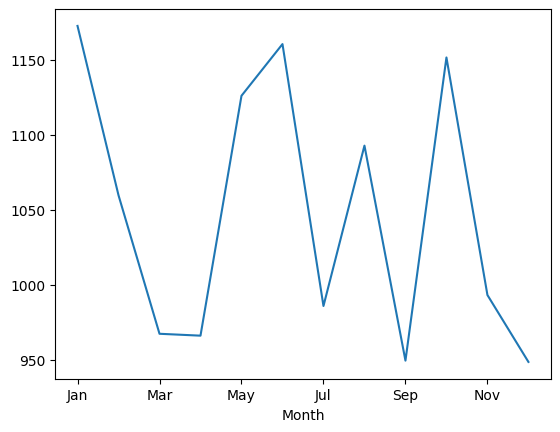

In [16]:
df.groupby('Month',observed=True)['TotalPrice'].mean().plot(kind='line')

In [17]:
df['YearMonth'] = df['Date'].dt.to_period('M')

<Axes: xlabel='YearMonth'>

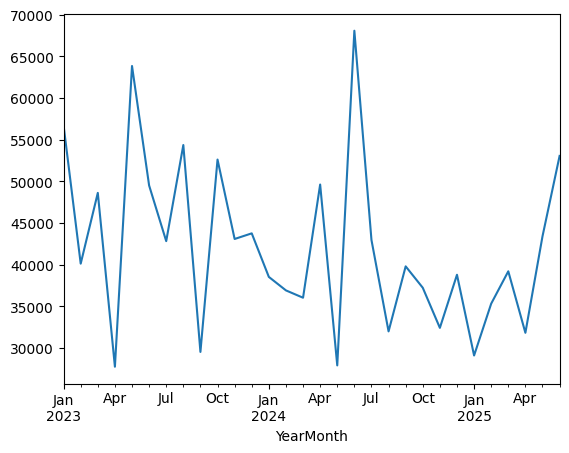

In [18]:
df.groupby('YearMonth')['TotalPrice'].sum().plot(kind='line')

<Axes: xlabel='Month'>

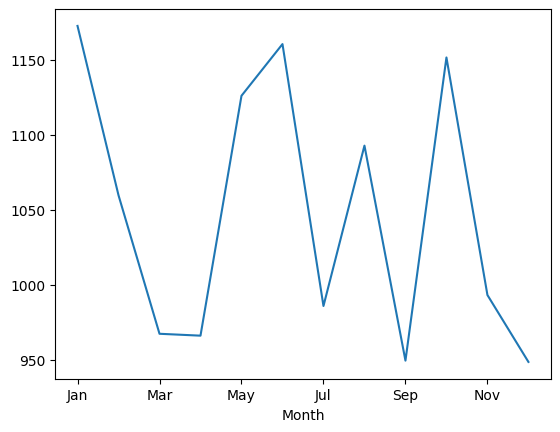

In [19]:
df.groupby('Month',observed=True)['TotalPrice'].mean().plot(kind='line')

<Axes: xlabel='Product'>

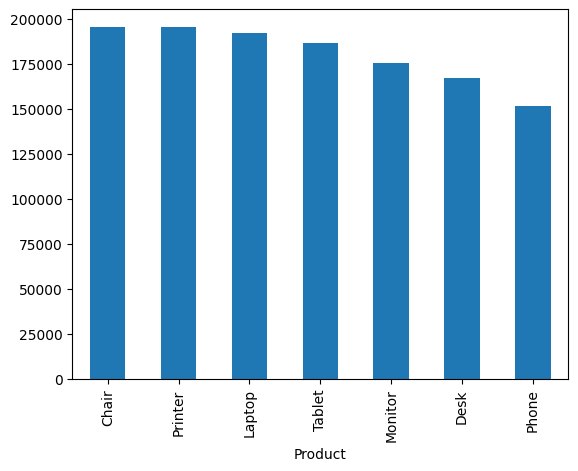

In [20]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='PaymentMethod'>

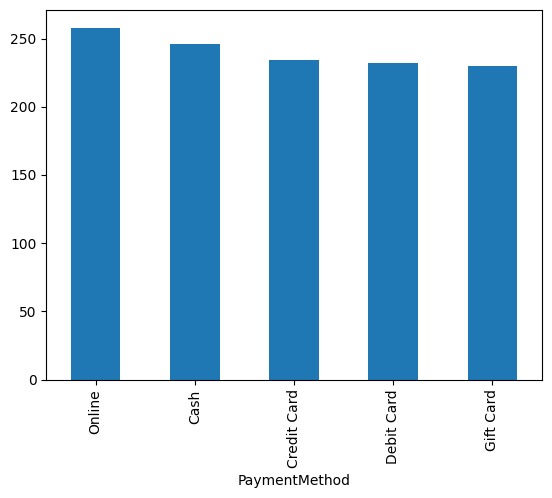

In [21]:
df['PaymentMethod'].value_counts().plot(kind='bar')

<Axes: xlabel='OrderStatus'>

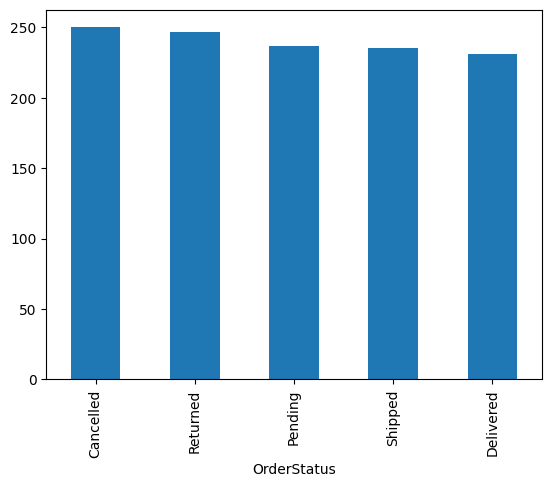

In [22]:
df['OrderStatus'].value_counts().plot(kind='bar')

<Axes: xlabel='TotalPrice'>

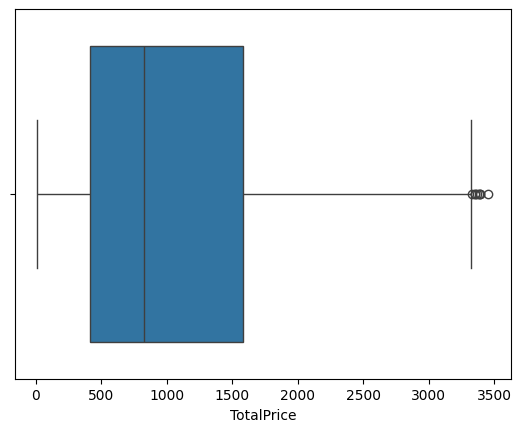

In [23]:
sns.boxplot(x=df['TotalPrice'])

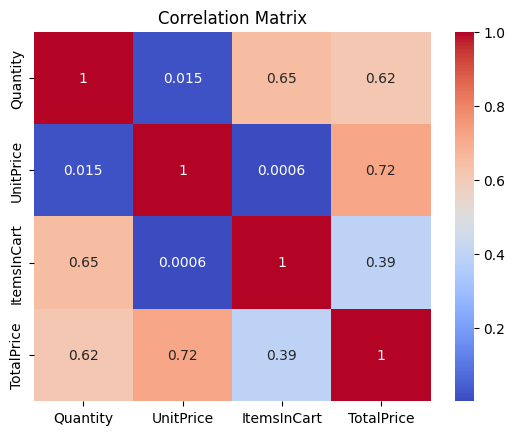

In [24]:
corr = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<Axes: ylabel='count'>

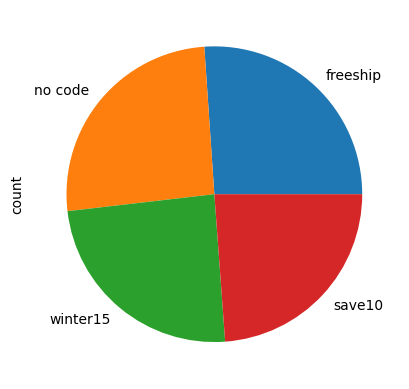

In [25]:
df['CouponCode'].value_counts().plot(kind='pie')